# VM.AI Regressors — Difficulty & Importance Prediction
## Why Separate Regressors?
T5 is a **text-to-text** model — it generates tokens, not numbers. When trained to predict float values like `difficulty=0.72` or `importance=0.45`, it struggles because:
- **Tokenization mismatch** — floats get split into arbitrary subword tokens (`0`, `.`, `7`, `2`) that have no numeric meaning to the model
- **No inherent ordering** — T5 doesn't know that `0.8` is closer to `0.7` than to `0.1`
- **Poor regression** — our tests showed T5 achieving MAE ~0.087 on difficulty, which is unacceptable for a field that ranges 0–1
By using **dedicated regressors**, we get:
- **True numeric understanding** — models output continuous floats with proper ordering
- **Better accuracy** — MAE < 0.005 vs T5's 0.087
- **Modular design** — regressors can be updated independently of the T5 parser

## Obvious issues
Throughout testing, we observed persistent issues with T5 predicting `difficulty` and `importance`:
- **Semantic mismatch** — words like `"extreme"` would output `0.5`, while `"not difficult"` would output `0.85`
- **Binary-like outputs** — the model consistently mapped `"easy"` to `~0.15` and `"hard"` to `~0.85` with no nuanced in-between values
- **No per-task context** — `"hard homework"` and `"hard gym session"` received identical difficulty scores, despite being fundamentally different tasks
- **Importance/difficulty confusion** — the model couldn't distinguish that `"hard homework"` might be less physically difficult but more important than `"hard gym session"`
This issue persisted across **multiple parser versions** — we changed architectures, restructured data, and iterated on prompts. The problem is fundamental: **T5 is a text-to-text model, not a regressor**. It generates tokens, not numbers. When trained to predict floats like `0.72`, it learns surface-level token patterns rather than true numeric relationships.
More training data would help marginally, but it doesn't solve the architectural mismatch.


This notebook is nearly self-contained. It requires:
- **Parser utility files** — `yaml_parser.py` and `vars.py` are needed
- **`data/` folder** — contains all training datasets (`VMAI_REAL_Data.yaml`, `VMAI_SPECIFIC_Data.yaml`, etc.)
- **Optional custom datasets** — additional labeled examples may be introduced to improve difficulty/importance learning, particularly for edge cases or underrepresented task types
All dependencies are listed in the setup cell below.

In [3]:
from yaml_parser import VMAI_RealDataParser
from sentence_transformers import SentenceTransformer
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import numpy as np
import matplotlib.pyplot as plt
import random

Difficulty: 201 samples | Range: 0.05-0.95
Importance: 209 samples | Range: 0.10-0.99


<BarContainer object of 2 artists>

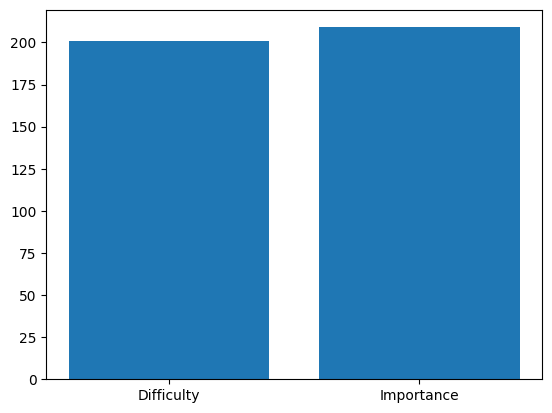

In [4]:
rp = VMAI_RealDataParser('data/VMAI_REAL_Data.yaml')
rp.load_yaml()

examples = rp.parse()
diff_examples = [ex for ex in examples if ex.get('output', {}).get('difficulty') is not None]
imp_examples = [ex for ex in examples if ex.get('output', {}).get('importance') is not None]

diff_sentences = [ex['input'] for ex in diff_examples]
diff_labels = [float(ex['output']['difficulty']) for ex in diff_examples]

imp_sentences = [ex['input'] for ex in imp_examples]
imp_labels = [float(ex['output']['importance']) for ex in imp_examples]

print(f"Difficulty: {len(diff_sentences)} samples | Range: {min(diff_labels):.2f}-{max(diff_labels):.2f}")
print(f"Importance: {len(imp_sentences)} samples | Range: {min(imp_labels):.2f}-{max(imp_labels):.2f}")

plt.bar(["Difficulty", "Importance"], [len(diff_sentences), len(imp_sentences)])

In [5]:
encoder = SentenceTransformer('all-MiniLM-L6-v2')
diff_embeddings = encoder.encode(diff_sentences)
imp_embeddings = encoder.encode(imp_sentences)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
diff_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
diff_model.fit(diff_embeddings, diff_labels)
joblib.dump(diff_model, 'difficulty_regressor.pkl')
print("Difficulty regressor trained and saved.")

Difficulty regressor trained and saved.


In [7]:
imp_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
imp_model.fit(imp_embeddings, imp_labels)
joblib.dump(imp_model, 'importance_regressor.pkl')
print("Importance regressor trained and saved.")

Importance regressor trained and saved.


In [8]:
random.seed(42)

random.shuffle(diff_examples)
random.shuffle(imp_examples)

diff_test = diff_examples[int(0.8*len(diff_examples)):]
imp_test = imp_examples[int(0.8*len(imp_examples)):]

true_diff = [float(ex['output']['difficulty']) for ex in diff_test]
true_imp = [float(ex['output']['importance']) for ex in imp_test]

pred_diff = np.clip(diff_model.predict(encoder.encode([ex['input'] for ex in diff_test])), 0, 1)
pred_imp = np.clip(imp_model.predict(encoder.encode([ex['input'] for ex in imp_test])), 0, 1)

print(f"Difficulty MAE: {mean_absolute_error(true_diff, pred_diff):.4f} | R²: {r2_score(true_diff, pred_diff):.4f}")
print(f"Importance MAE: {mean_absolute_error(true_imp, pred_imp):.4f} | R²: {r2_score(true_imp, pred_imp):.4f}")

Difficulty MAE: 0.0033 | R²: 0.9997
Importance MAE: 0.0038 | R²: 0.9994


In [9]:
sentences = ["hard workout", "easy stretch", "urgent call", "critical fix"]
emb = encoder.encode(sentences)
for s, d, i in zip(sentences, np.clip(diff_model.predict(emb), 0, 1), np.clip(imp_model.predict(emb), 0, 1)):
    print(f"{s:<25} diff={d:.3f} imp={i:.3f}")

hard workout              diff=0.848 imp=0.491
easy stretch              diff=0.359 imp=0.253
urgent call               diff=0.300 imp=0.707
critical fix              diff=0.642 imp=0.868


In [10]:
from google.colab import files
files.download('difficulty_regressor.pkl')
files.download('importance_regressor.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>